# Titanic Survival Prediction — Exploratory Data Analysis

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid", palette="Paired")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.constrained_layout.use"] = True

%matplotlib inline


## 2. Load the Dataset

In [ ]:
df = pd.read_csv("data/titanic.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)


Dataset shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## 3. Dataset Overview

In [ ]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# Statistical summary of numerical columns
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Statistical summary of categorical columns
df.describe(include="string")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 4. Missing Values Analysis

In [ ]:
# Count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing


Columns with missing values:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


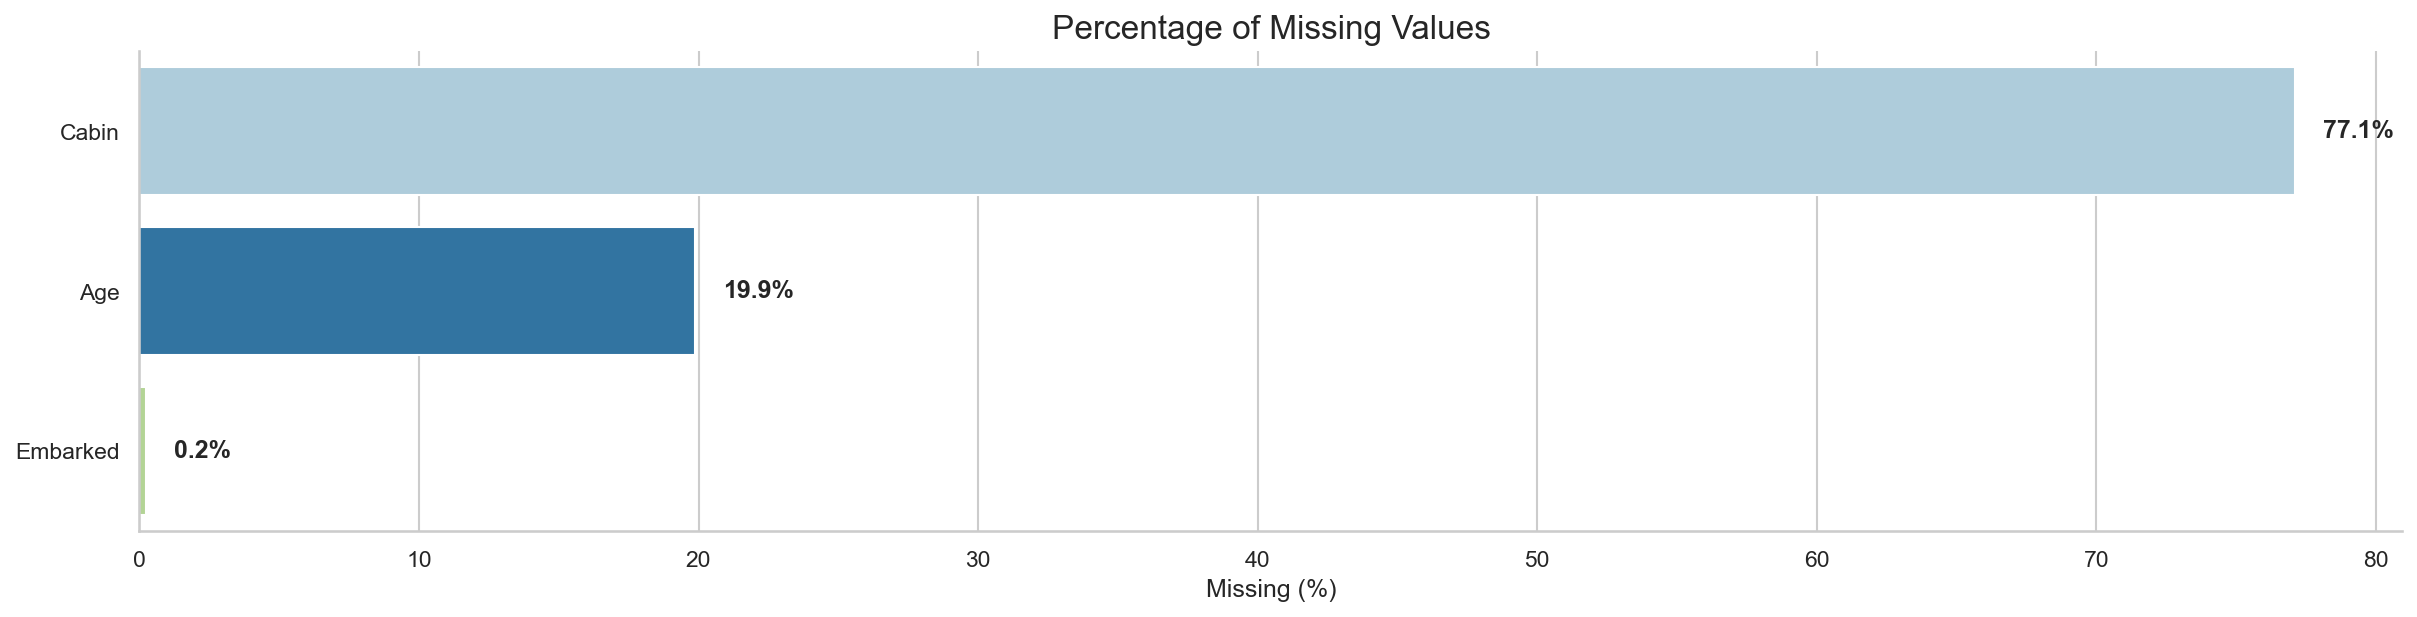

In [ ]:
figure, ax = plt.subplots(figsize=(16, 4))

sns.barplot(y=missing.index, x=missing["Missing %"], hue=missing.index, ax=ax)

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 1,  
        bar.get_y() + bar.get_height()/2,
        f"{width.round(1)}%",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

plt.xlabel("Missing (%)")
plt.ylabel(None)
plt.title("Percentage of Missing Values", fontsize=16)
plt.show()

**Key observations:**

- **Cabin** has ~77% missing values — too many to impute reliably, we'll likely drop it

- **Age** has ~20% missing — we can impute using group medians

- **Embarked** has only 2 missing values — easy to fill with the mode

## 5. Target Variable Analysis

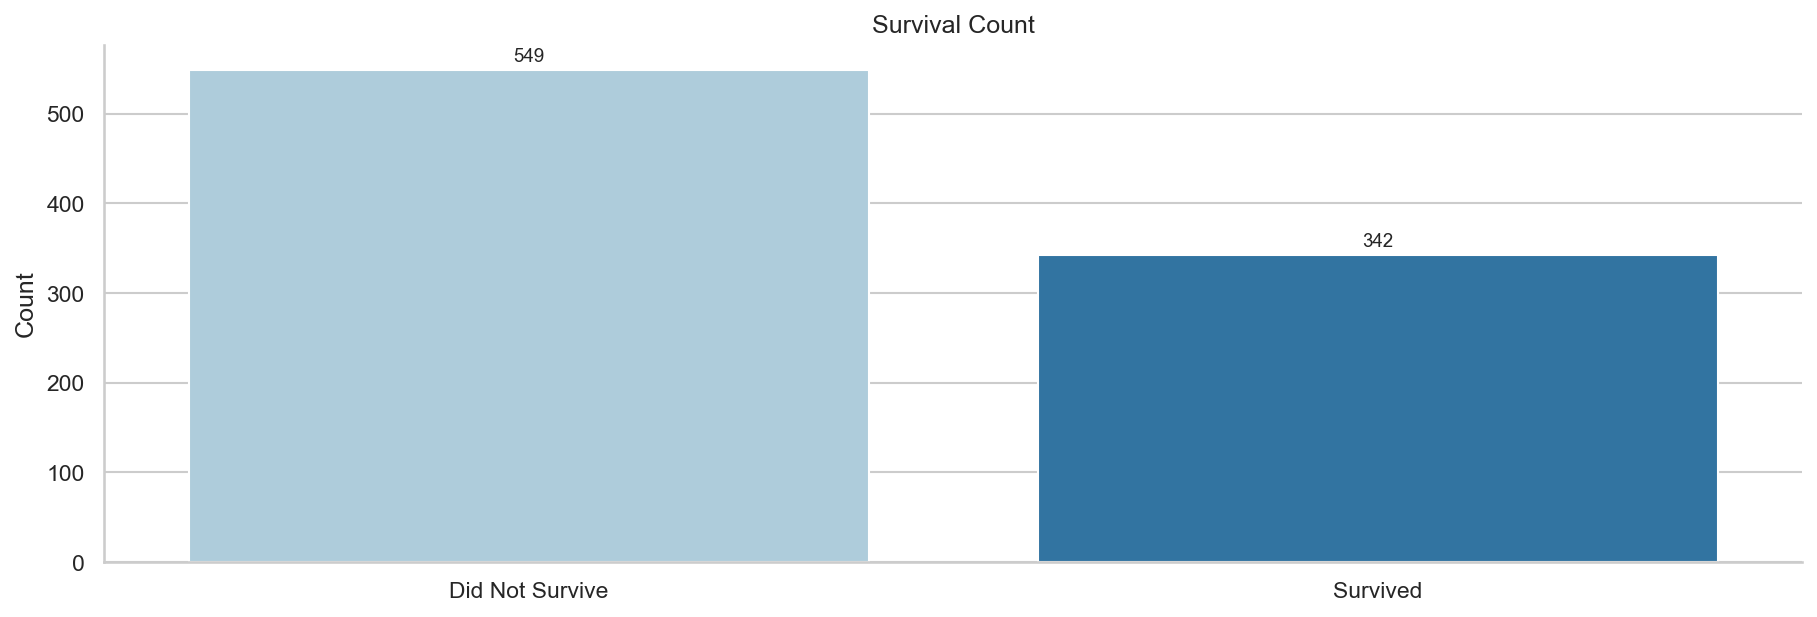


Survival rate: 38.38%
Death rate: 61.62%


Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
# Survival distribution
fig, ax = plt.subplots(figsize=(12, 4))

# Count plot
survived_counts = df["Survived"].value_counts()
sns.barplot(x=["Did Not Survive", "Survived"], y=survived_counts.values, hue=["Did Not Survive", "Survived"], ax=ax)
ax.set_title("Survival Count")
ax.set_ylabel("Count")

for bar in ax.patches:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

print(f"\nSurvival rate: {df['Survived'].mean():.2%}")
print(f"Death rate: {1 - df['Survived'].mean():.2%}")

survived_counts

The dataset is **imbalanced** — about 38% survived and 62% did not. 

## 6. Univariate Analysis — Numerical Features

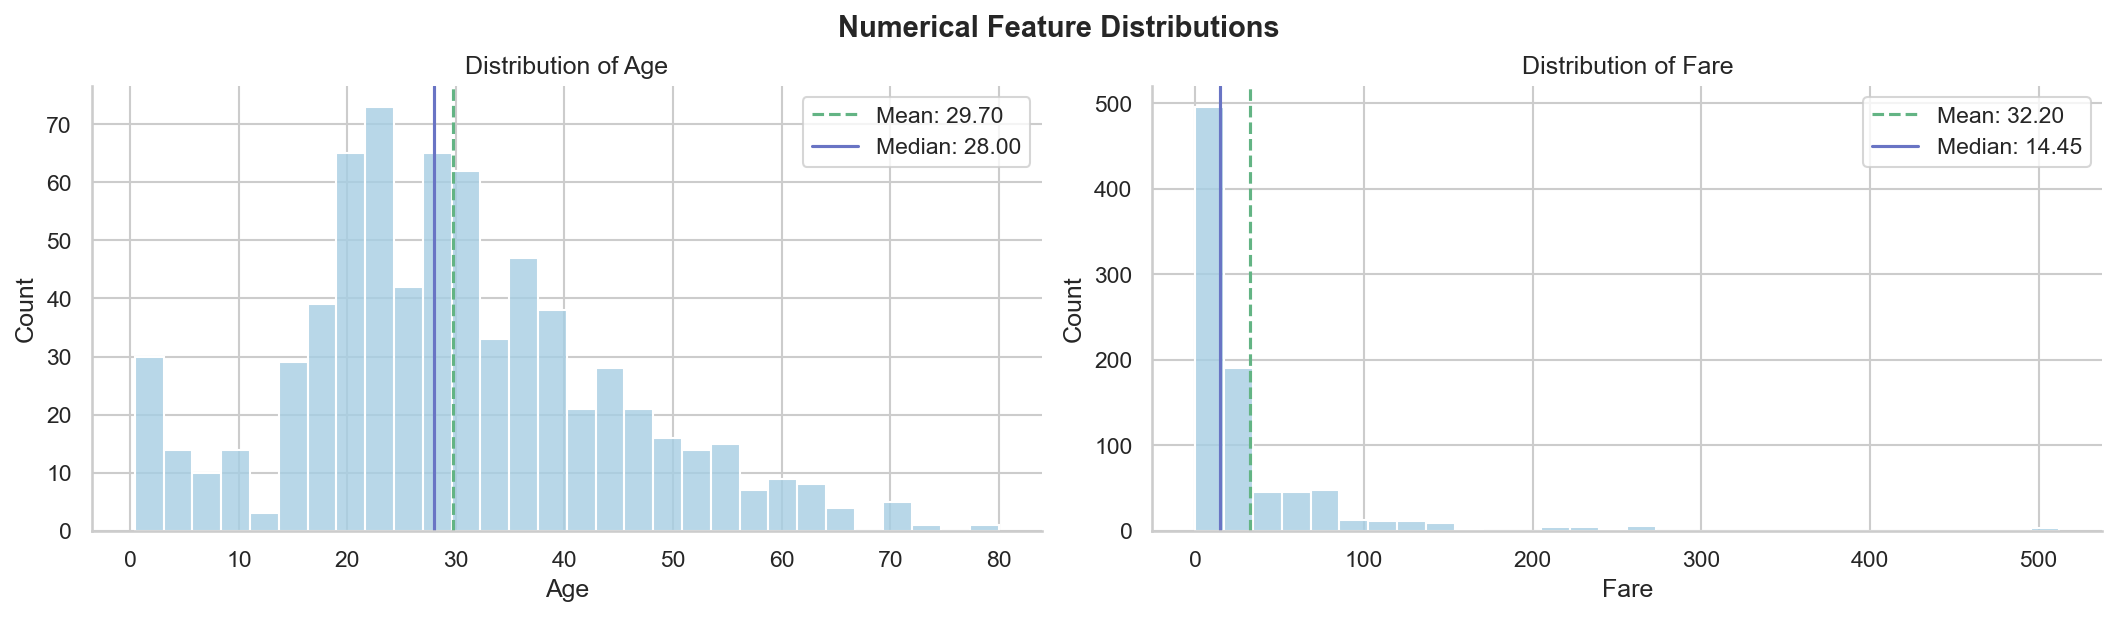

In [ ]:
# Distribution of numerical features
numerical_cont = ["Age", "Fare"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cont):
    sns.histplot(df[col].dropna(), bins=30, edgecolor="white", alpha=0.8, ax=axes[i])
    axes[i].axvline(df[col].mean(), color="#63b484", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="#6974c4", linestyle="-", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions (Continuous Variables)", fontsize=14, fontweight="bold")
plt.show()


- Most passengers were young adults, with an average age around 30 years.

- Fare is highly skewed, indicating that most passengers paid low fares while a small group paid significantly higher prices.

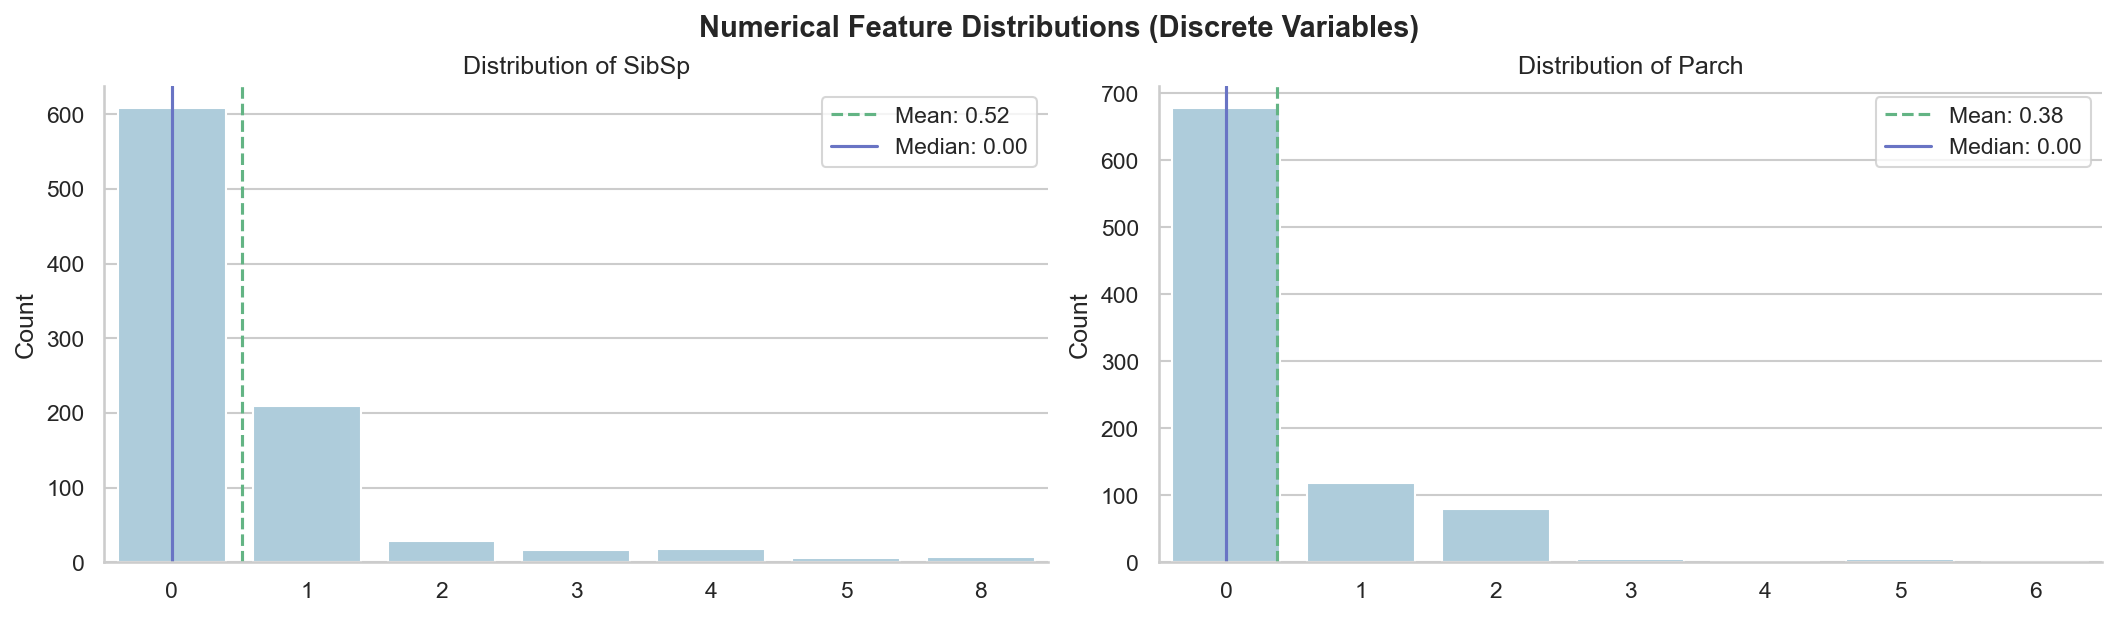

In [ ]:
numerical_disc = ['SibSp', 'Parch']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_disc):
    sns.countplot(x=df[col].dropna(), ax=axes[i])
    axes[i].axvline(df[col].mean(), color="#63b484", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="#6974c4", linestyle="-", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(None)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions (Discrete Variables)", fontsize=14, fontweight="bold")
plt.show()

- Data in both features is skewed.

- Most passengers traveled alone or with small families.

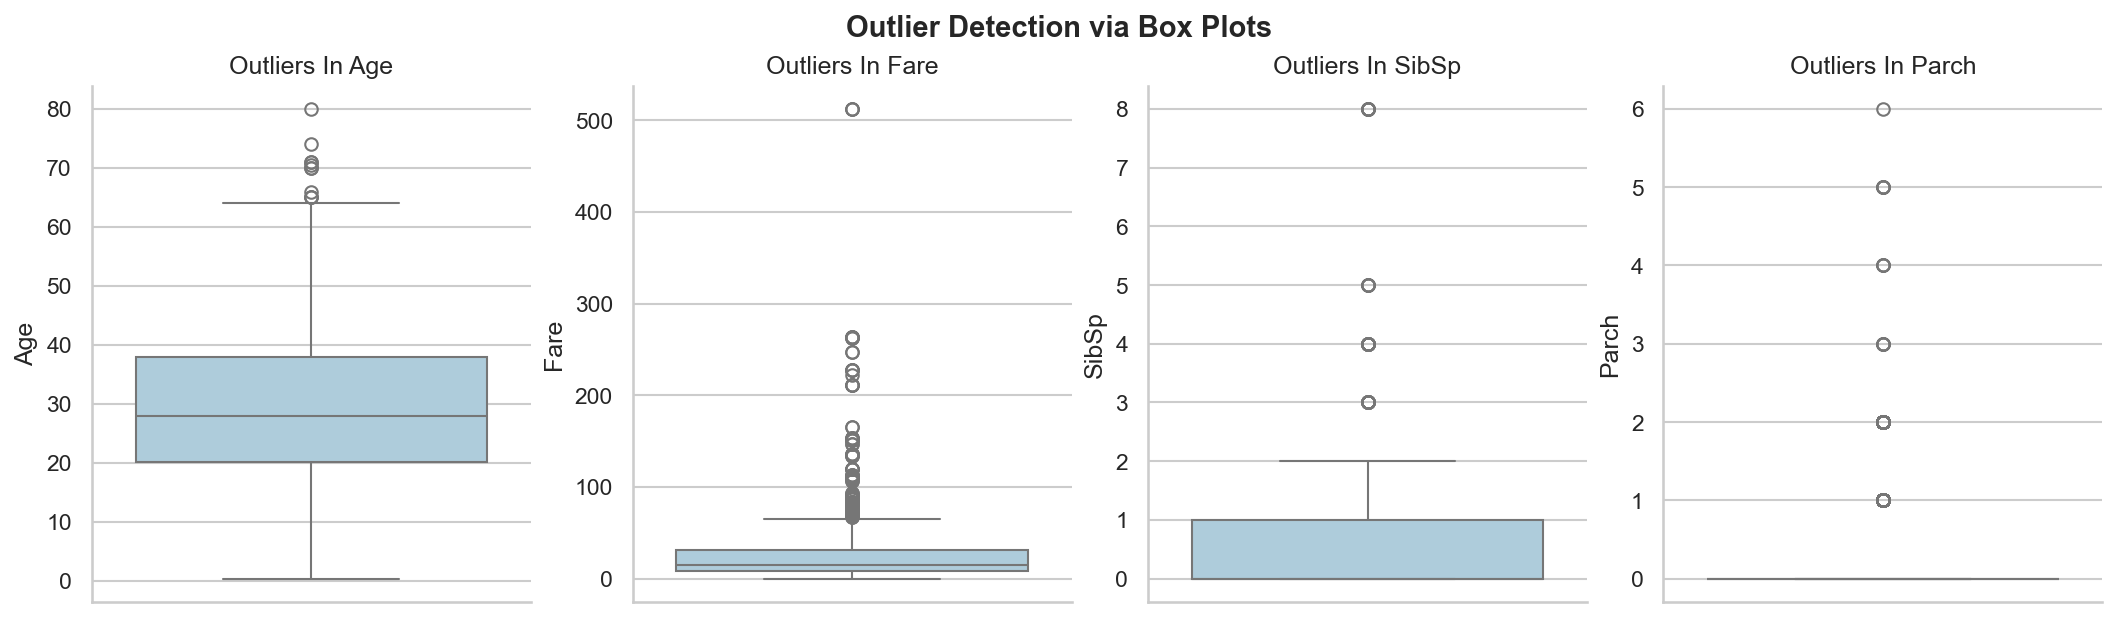

In [ ]:
# Box plots to check for outliers
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f"Outliers In {col}")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.show()


**Observations:**

- **Age**: A few passengers were much older than the rest (around 65–80 years), but these represent real passengers, not data errors.

- **Fare**: This feature contains the largest number of outliers, with a small group of passengers paying exceptionally high fares. This explains why Fare is strongly right-skewed.

- **SibSp & Parch**: most passengers traveled alone or with 1-2 family members.

## 7. Univariate Analysis — Categorical Features

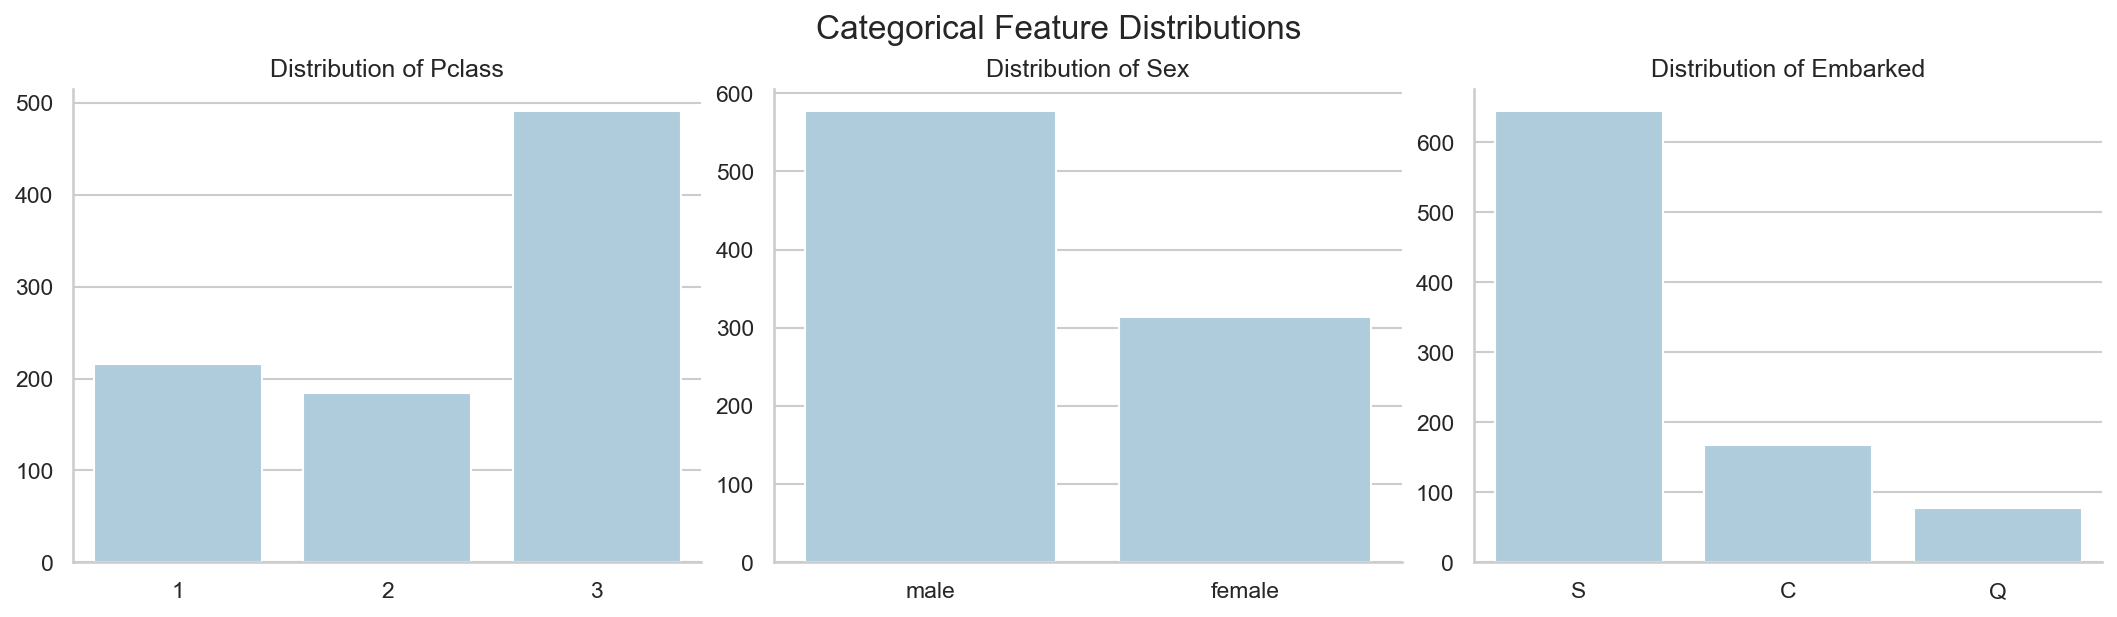

In [ ]:
# Distribution of categorical features
categorical_cols = ["Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel(None)
    axes[i].set_xlabel(None)
  
plt.suptitle("Categorical Feature Distributions", fontsize=16)
plt.show()



**Observations:**

- **Pclass**: most passengers traveled in 3rd class, indicating that the dataset is dominated by lower-class travelers.

- **Sex**: there are considerably more male passengers than female passengers.

- **Embarked**: the majority of passengers boarded at Southampton (S).

## 8. Bivariate Analysis — Survival vs Features

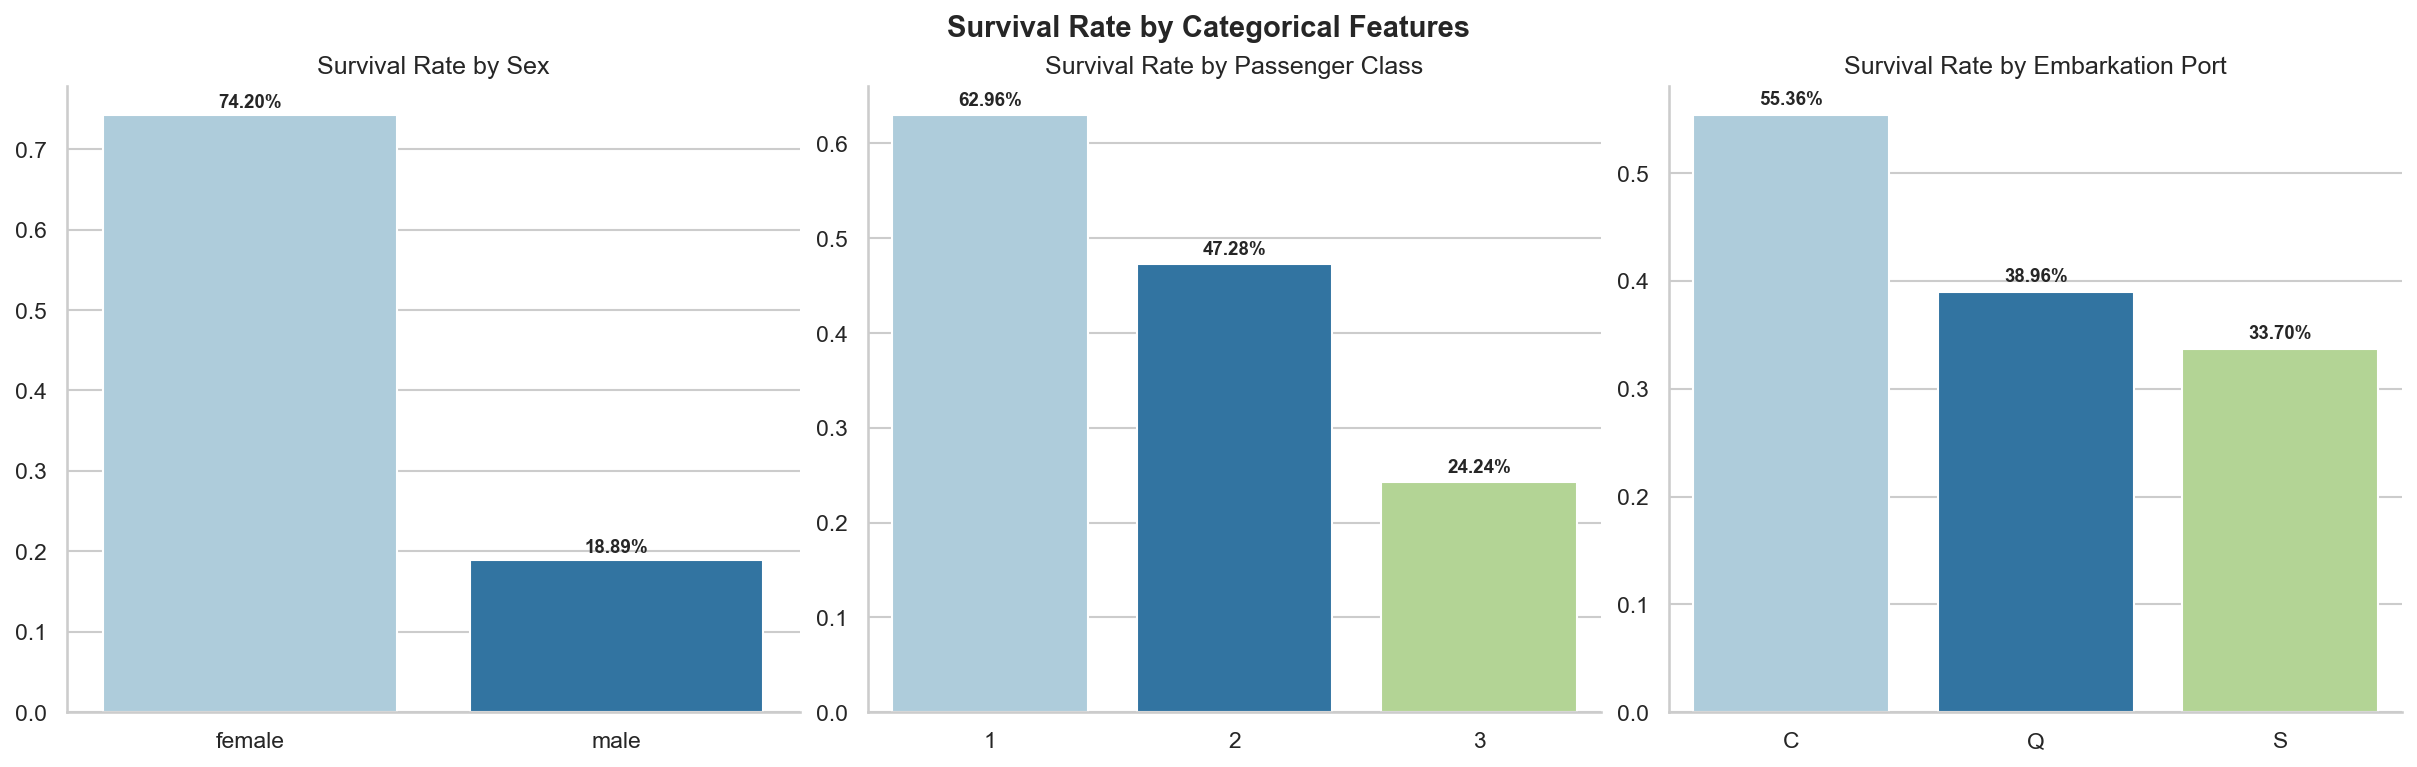

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plots = [
    ("Sex", "Survival Rate by Sex"),
    ("Pclass", "Survival Rate by Passenger Class"),
    ("Embarked", "Survival Rate by Embarkation Port")
]

for ax, (col, title) in zip(axes, plots):

    survival_rate = df.groupby(col)["Survived"].mean()

    sns.barplot(
        x=survival_rate.index.astype(str),
        y=survival_rate.values,
        hue=survival_rate.index.astype(str),
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(None)
    ax.set_ylabel(None)

    for x, y in enumerate(survival_rate.values):
        ax.text(
            x,
            y + 0.01,
            f"{y:.2%}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

plt.suptitle(
    "Survival Rate by Categorical Features",
    fontsize=14,
    fontweight="bold"
)

plt.show()
survival_rate

**Key findings:**

- **Women had a higher survival rate** (~74%) than men (~19%).

- First-class passengers had better outcomes compared to lower classes.

- **Passenger that boarded at Cherbourg** had the highest survival rate. Most 1st class passengers boarded there.

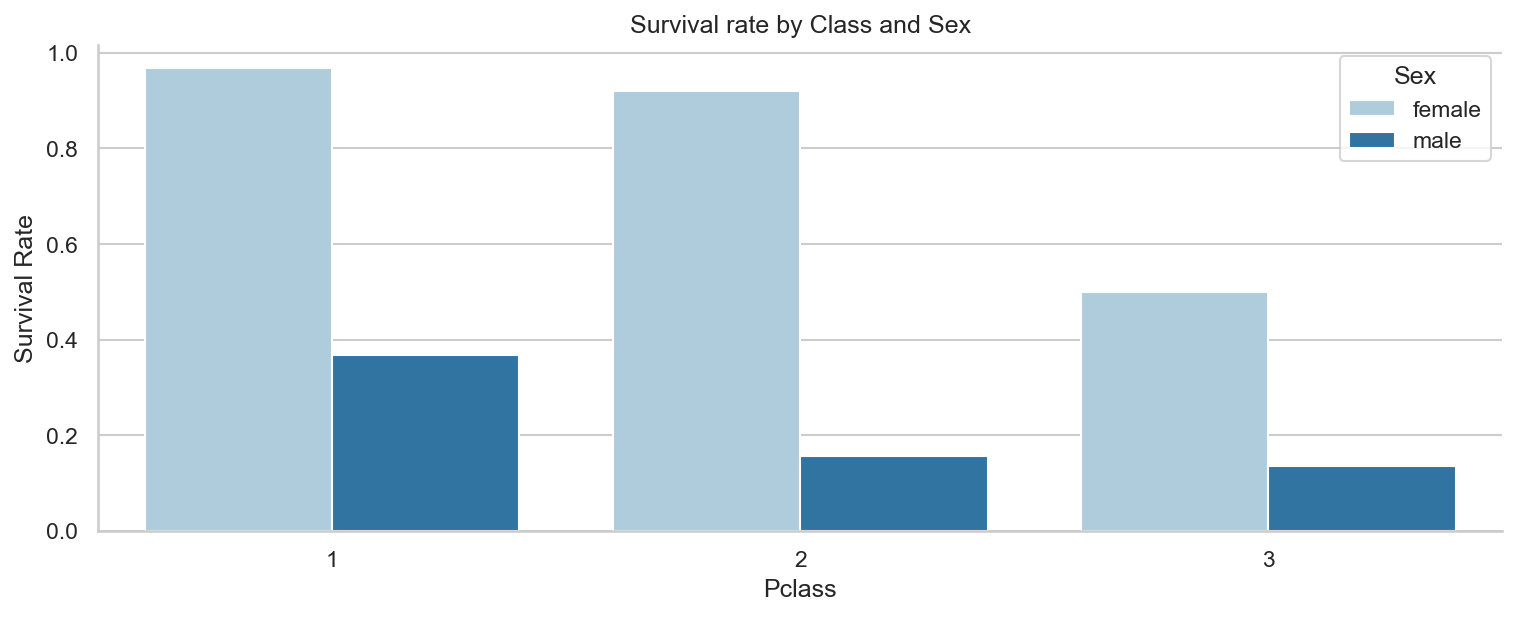

In [ ]:
# Survival by Sex and Pclass combined
fig, ax = plt.subplots()

survival_grouped = df.groupby(["Pclass", "Sex"]).agg(
    survival_rate = ("Survived", "mean")
).reset_index()

sns.barplot(data=survival_grouped, x='Pclass', y='survival_rate', hue='Sex', ax=ax)

plt.title("Survival rate by Class and Sex")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.show()


- Women survived more across all classes.

- The higher the class, the higher the survival rate.

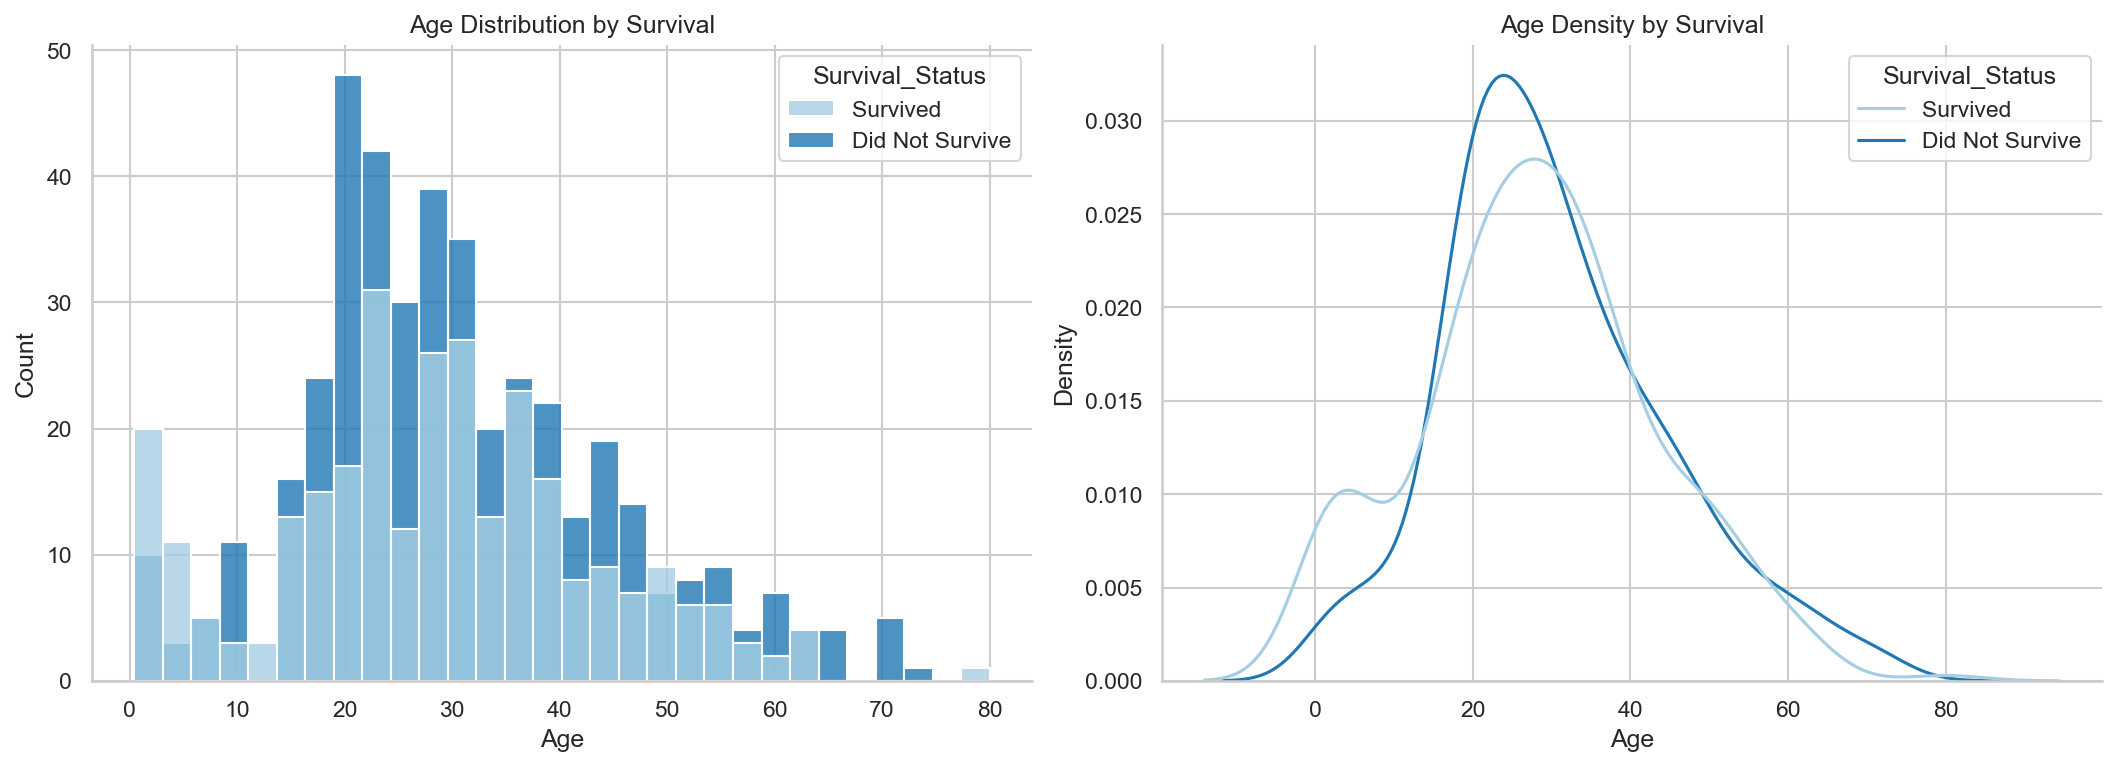

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["Survival_Status"] = df["Survived"].map({
    0: "Did Not Survive",
    1: "Survived",
})

# Histogram
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    multiple="layer",
    alpha=0.8,
    edgecolor="white",
    ax=axes[0]
)

# KDE
sns.kdeplot(
    data=df,
    x="Age",
    hue="Survived",
    common_norm=False,
    ax=axes[1]
)

axes[0].set_title("Age Distribution by Survival")
axes[1].set_title("Age Density by Survival")


plt.show()

**Observations:**

- There appears to be a higher concentration of survivors among young children (< 10 years old) compared to non-survivors.

- Creating an age-group feature (e.g., Child, Teenager, Adult, Senior) could help further investigate whether survival rates differed across age categories and provide stronger evidence for this pattern.

## 10. Correlation Analysis

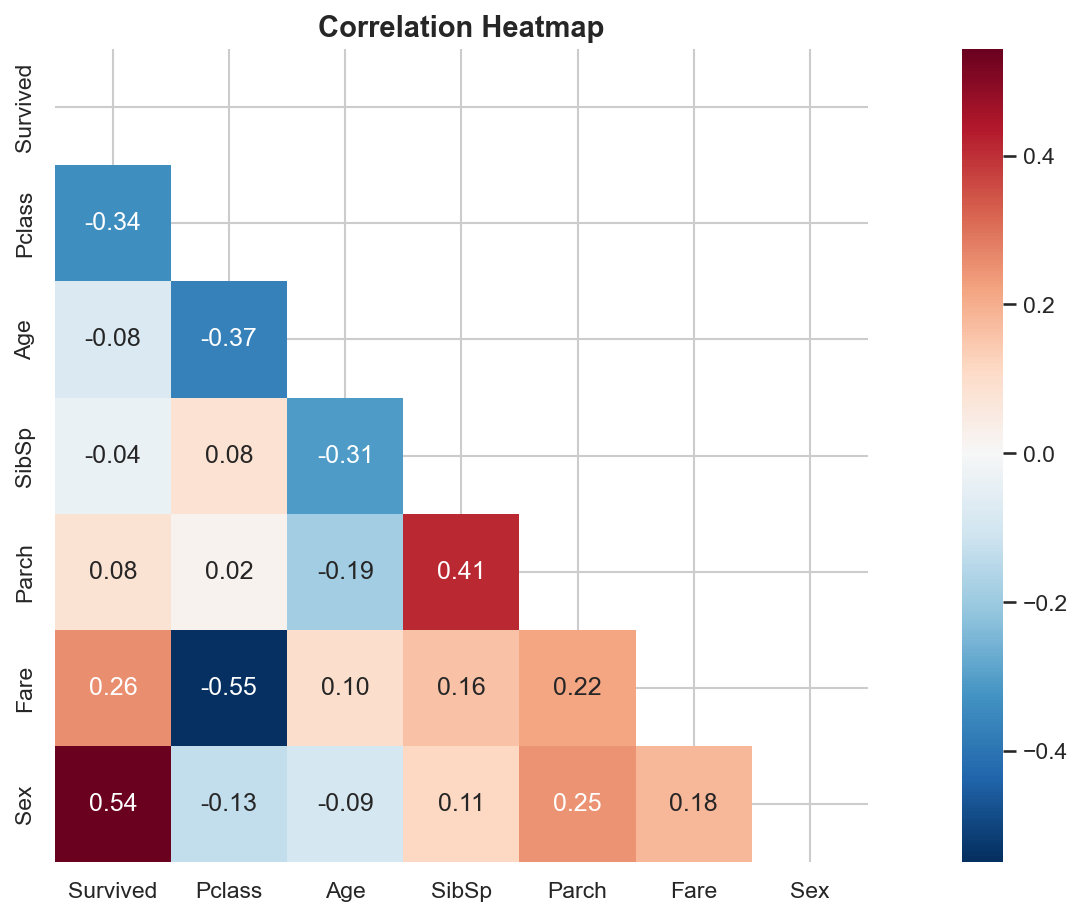

          Survived    Pclass       Age     SibSp     Parch      Fare       Sex
Survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307  0.543351
Pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500 -0.131900
Age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067 -0.093254
SibSp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651  0.114631
Parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225  0.245489
Fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000  0.182333
Sex       0.543351 -0.131900 -0.093254  0.114631  0.245489  0.182333  1.000000


In [16]:
# Correlation heatmap of numerical features
numeric_df = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].copy()
numeric_df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    center=0,
    square=True, 
    ax=ax
)

ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

print(corr)


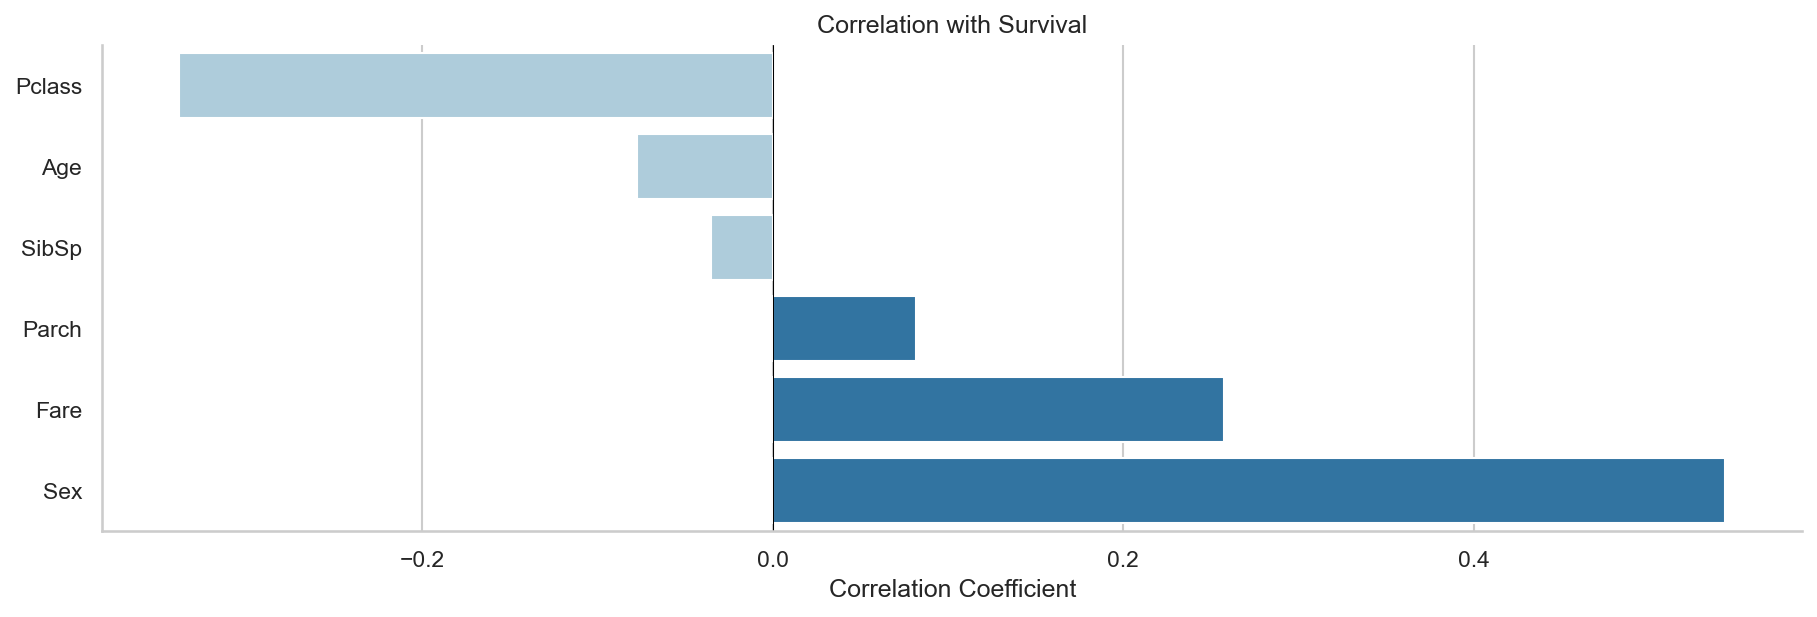

Pclass   -0.338481
Age      -0.077221
SibSp    -0.035322
Parch     0.081629
Fare      0.257307
Sex       0.543351
Name: Survived, dtype: float64

In [127]:
# Correlation with target
target_corr = corr["Survived"].drop("Survived").sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=target_corr.values, y=target_corr.index, ax=ax, hue=target_corr.values > 0)
ax.get_legend().remove()
plt.axvline(x=0, color="black", linewidth=0.5)
plt.xlabel("Correlation Coefficient")
plt.ylabel(None)
plt.title("Correlation with Survival")
plt.show()

target_corr


**Key correlations with Survival:**

- **Sex**: Shows the strongest relationship with survival, making it the most informative single feature in the dataset.

- **Fare**: is positively associated with survival.

- **Pclass** and **Fare** have the strongest feature-to-feature correlation.

- **Age**: slight negative correlation with survival — younger passengers had slightly better chances.